In [1]:
!pip install -q openpyxl plotly scikit-learn scipy seaborn

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, adjusted_rand_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
sns.set_style("whitegrid")
RS = 42

In [2]:
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
!wget -q {url} -O retail.zip && unzip -o -q retail.zip
df = pd.read_excel("Online Retail.xlsx")
print(df.shape); df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(df.isna().sum())
n0 = len(df)
df = df.dropna(subset=["CustomerID"])                              # missing customers
df = df.drop_duplicates()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]          # cancellations
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]              # invalid rows
df["CustomerID"] = df["CustomerID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
print(f"Rows: {n0} -> {len(df)} | Customers: {df.CustomerID.nunique()}")

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Rows: 541909 -> 392692 | Customers: 4338


                      count         mean          std       min         25%  \
Recency              4338.0    92.536422   100.014169  1.000000   18.000000   
Frequency            4338.0     4.272015     7.697998  1.000000    1.000000   
Monetary             4338.0  2048.688081  8985.230220  3.750000  306.482500   
AvgTransactionValue  4338.0   417.645735  1796.511343  3.450000  177.867083   
TotalQuantity        4338.0  1187.644537  5043.619654  1.000000  159.000000   
PurchaseFrequency    4338.0     0.902413     0.797875  0.151899    0.529412   

                        50%          75%            max  
Recency               51.00   142.000000     374.000000  
Frequency              2.00     5.000000     209.000000  
Monetary             668.57  1660.597500  280206.020000  
AvgTransactionValue  291.94   428.280625   84236.250000  
TotalQuantity        378.00   989.750000  196915.000000  
PurchaseFrequency      1.00     1.000000      32.903226  


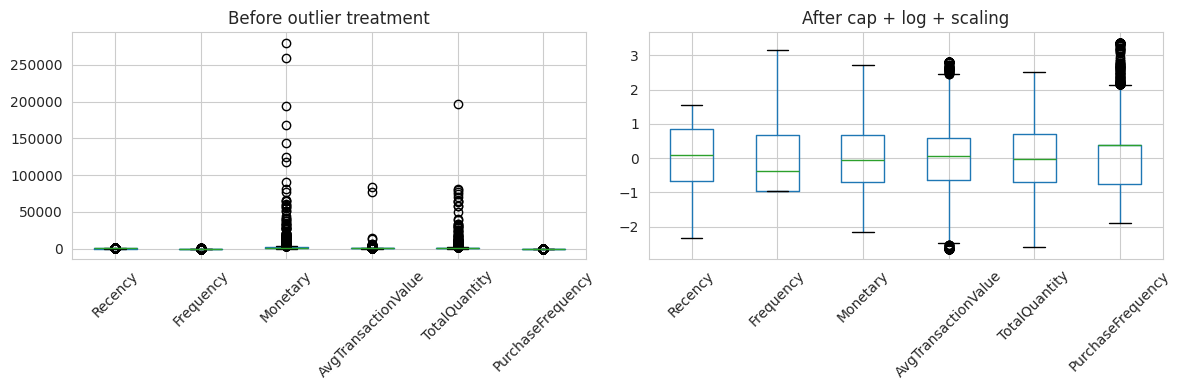

In [4]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
)
cust["AvgTransactionValue"] = cust["Monetary"] / cust["Frequency"]
months_active = ((cust["LastPurchase"] - cust["FirstPurchase"]).dt.days / 30) + 1
cust["PurchaseFrequency"] = cust["Frequency"] / months_active      # orders per month
cust = cust.drop(columns=["FirstPurchase", "LastPurchase"])

FEATURES = ["Recency", "Frequency", "Monetary", "AvgTransactionValue", "TotalQuantity", "PurchaseFrequency"]
print(cust[FEATURES].describe().T)

# Outlier treatment: winsorize at 1st/99th percentile -> log transform -> standardize
capped = cust[FEATURES].clip(cust[FEATURES].quantile(0.01), cust[FEATURES].quantile(0.99), axis=1)
logged = np.log1p(capped)
scaler = StandardScaler()
X = scaler.fit_transform(logged)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cust[FEATURES].boxplot(ax=ax[0]); ax[0].set_title("Before outlier treatment"); ax[0].tick_params(axis="x", rotation=45)
pd.DataFrame(X, columns=FEATURES).boxplot(ax=ax[1]); ax[1].set_title("After cap + log + scaling"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

                      count         mean          std       min         25%  \
Recency              4338.0    92.536422   100.014169  1.000000   18.000000   
Frequency            4338.0     4.272015     7.697998  1.000000    1.000000   
Monetary             4338.0  2048.688081  8985.230220  3.750000  306.482500   
AvgTransactionValue  4338.0   417.645735  1796.511343  3.450000  177.867083   
TotalQuantity        4338.0  1187.644537  5043.619654  1.000000  159.000000   
PurchaseFrequency    4338.0     0.902413     0.797875  0.151899    0.529412   

                        50%          75%            max  
Recency               51.00   142.000000     374.000000  
Frequency              2.00     5.000000     209.000000  
Monetary             668.57  1660.597500  280206.020000  
AvgTransactionValue  291.94   428.280625   84236.250000  
TotalQuantity        378.00   989.750000  196915.000000  
PurchaseFrequency      1.00     1.000000      32.903226  


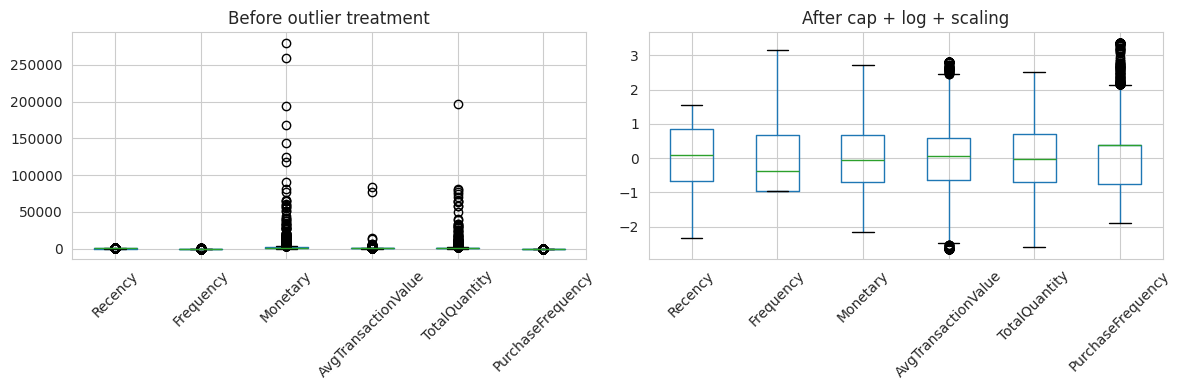

In [5]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
)
cust["AvgTransactionValue"] = cust["Monetary"] / cust["Frequency"]
months_active = ((cust["LastPurchase"] - cust["FirstPurchase"]).dt.days / 30) + 1
cust["PurchaseFrequency"] = cust["Frequency"] / months_active      # orders per month
cust = cust.drop(columns=["FirstPurchase", "LastPurchase"])

FEATURES = ["Recency", "Frequency", "Monetary", "AvgTransactionValue", "TotalQuantity", "PurchaseFrequency"]
print(cust[FEATURES].describe().T)

# Outlier treatment: winsorize at 1st/99th percentile -> log transform -> standardize
capped = cust[FEATURES].clip(cust[FEATURES].quantile(0.01), cust[FEATURES].quantile(0.99), axis=1)
logged = np.log1p(capped)
scaler = StandardScaler()
X = scaler.fit_transform(logged)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cust[FEATURES].boxplot(ax=ax[0]); ax[0].set_title("Before outlier treatment"); ax[0].tick_params(axis="x", rotation=45)
pd.DataFrame(X, columns=FEATURES).boxplot(ax=ax[1]); ax[1].set_title("After cap + log + scaling"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

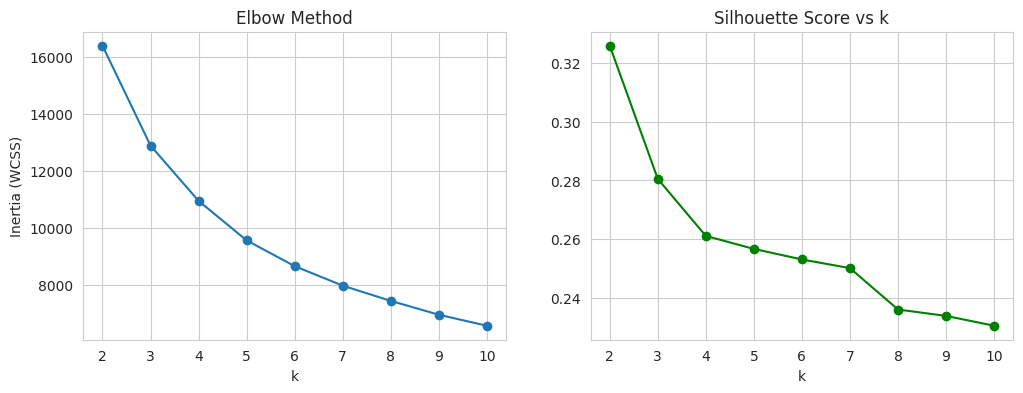

{2: np.float64(0.326), 3: np.float64(0.281), 4: np.float64(0.261), 5: np.float64(0.257), 6: np.float64(0.253), 7: np.float64(0.25), 8: np.float64(0.236), 9: np.float64(0.234), 10: np.float64(0.23)}


In [6]:
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia (WCSS)")
ax[1].plot(ks, sil, "o-", color="green"); ax[1].set_title("Silhouette Score vs k"); ax[1].set_xlabel("k")
plt.show()
print(dict(zip(ks, np.round(sil, 3))))

In [7]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RS).fit(X)
cust["KMeans"] = kmeans.labels_
sil_km = silhouette_score(X, cust["KMeans"])
print("K-Means silhouette:", round(sil_km, 4))
print(cust["KMeans"].value_counts().sort_index())

K-Means silhouette: 0.2611
KMeans
0    1055
1     719
2    1065
3    1499
Name: count, dtype: int64


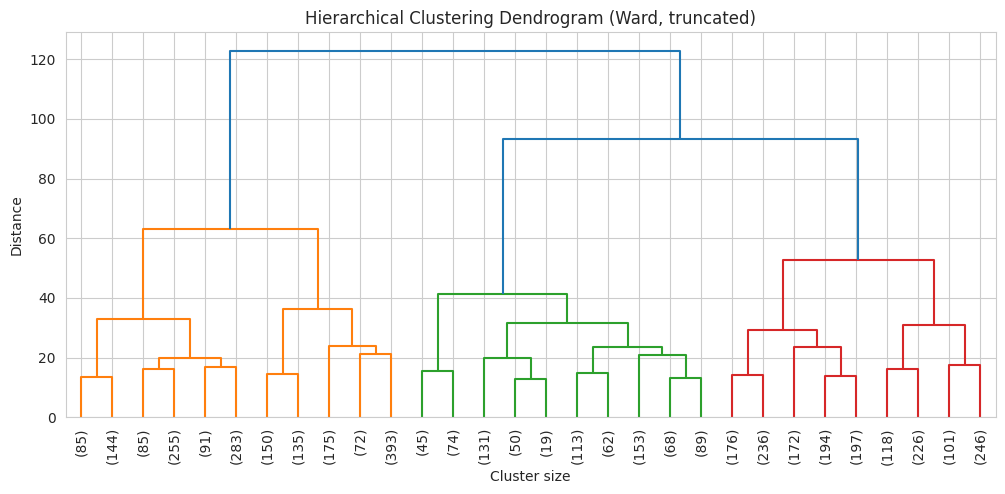

                Method  Silhouette
0              K-Means    0.261081
1  Hierarchical (Ward)    0.222485
Adjusted Rand Index (agreement between the two): 0.6431
Hierarchical     0    1    2    3
KMeans                           
0              185  817    0   53
1               62    2  652    3
2               55   90   56  864
3             1364   16   96   23


In [8]:
Z = linkage(X, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward, truncated)")
plt.xlabel("Cluster size"); plt.ylabel("Distance"); plt.show()

hc = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X)
cust["Hierarchical"] = hc.labels_
sil_hc = silhouette_score(X, cust["Hierarchical"])
ari = adjusted_rand_score(cust["KMeans"], cust["Hierarchical"])

print(pd.DataFrame({"Method": ["K-Means", "Hierarchical (Ward)"], "Silhouette": [sil_km, sil_hc]}))
print("Adjusted Rand Index (agreement between the two):", round(ari, 4))
print(pd.crosstab(cust["KMeans"], cust["Hierarchical"], rownames=["KMeans"], colnames=["Hierarchical"]))

Explained variance: [0.562 0.179] | total: 0.741


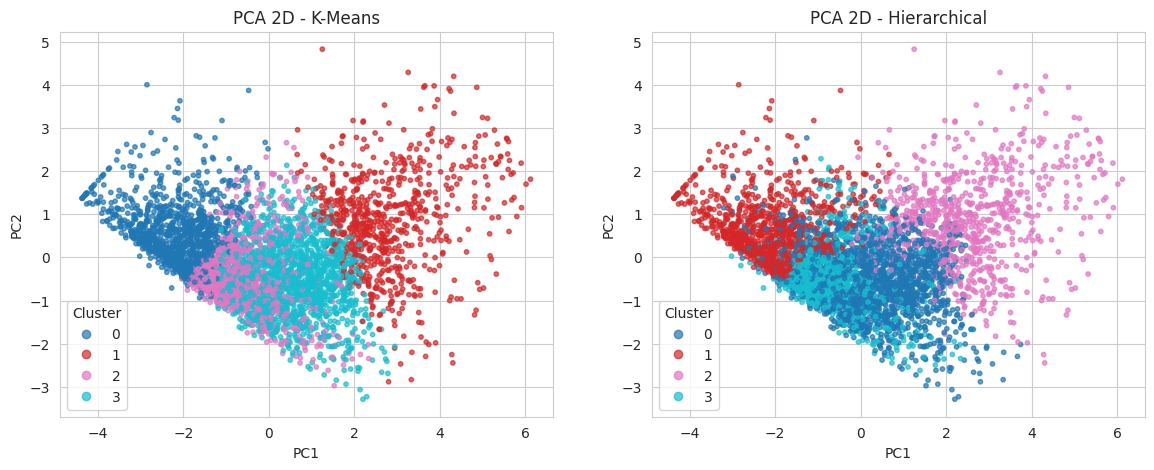

                       PC1    PC2
Recency             -0.344 -0.378
Frequency            0.457  0.354
Monetary             0.532 -0.111
AvgTransactionValue  0.346 -0.586
TotalQuantity        0.518 -0.107
PurchaseFrequency    0.042  0.603


In [9]:
pca = PCA(n_components=2, random_state=RS)
P2 = pca.fit_transform(X)
print("Explained variance:", pca.explained_variance_ratio_.round(3), "| total:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, col, t in zip(ax, ["KMeans", "Hierarchical"], ["K-Means", "Hierarchical"]):
    sc = a.scatter(P2[:, 0], P2[:, 1], c=cust[col], cmap="tab10", s=10, alpha=0.7)
    a.set_title(f"PCA 2D - {t}"); a.set_xlabel("PC1"); a.set_ylabel("PC2")
    a.legend(*sc.legend_elements(), title="Cluster")
plt.show()

print(pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"]).round(3))

,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,Customers,% Customers,% Revenue
KMeans,,,,,,,,,
0,155.57,1.46,189.41,140.51,106.60,0.97,1055,24.3,2.2
1,19.76,13.64,8384.19,796.02,4817.53,1.42,719,16.6,67.8
2,138.03,1.42,699.90,521.53,395.54,1.07,1065,24.6,8.4
3,50.76,3.79,1276.69,357.40,770.16,0.48,1499,34.6,21.5


{np.int32(1): 'High-Value Champions', np.int32(0): 'Dormant / At-Risk', 2: 'New / Occasional', 3: 'Loyal Regulars'}


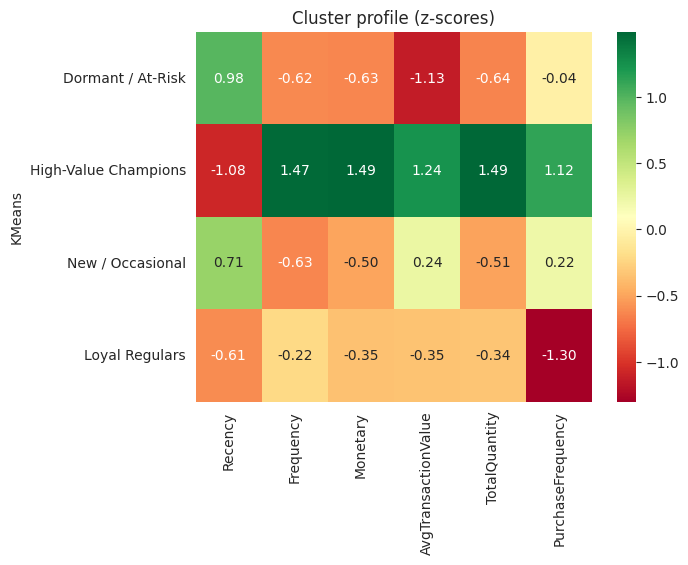

In [10]:
profile = cust.groupby("KMeans")[FEATURES].mean().round(2)
profile["Customers"] = cust["KMeans"].value_counts().sort_index()
profile["% Customers"] = (profile["Customers"] / len(cust) * 100).round(1)
profile["% Revenue"] = (cust.groupby("KMeans")["Monetary"].sum() / cust["Monetary"].sum() * 100).round(1)
display(profile)

# Auto-naming by behaviour
names = {}
hv = profile["Monetary"].idxmax();            names[hv] = "High-Value Champions"
rest = profile.drop(index=hv)
lost = rest["Recency"].idxmax();              names[lost] = "Dormant / At-Risk"
rest = rest.drop(index=lost)
for c in rest.index:
    names[c] = "Loyal Regulars" if rest.loc[c, "Frequency"] >= rest["Frequency"].median() else "New / Occasional"
cust["Segment"] = cust["KMeans"].map(names)
print(names)

# Heatmap of relative profile
sns.heatmap(((profile[FEATURES] - profile[FEATURES].mean()) / profile[FEATURES].std()).rename(index=names),
            annot=True, cmap="RdYlGn", fmt=".2f"); plt.title("Cluster profile (z-scores)"); plt.show()

HighValue
0    0.834255
1    0.165745
Name: proportion, dtype: float64


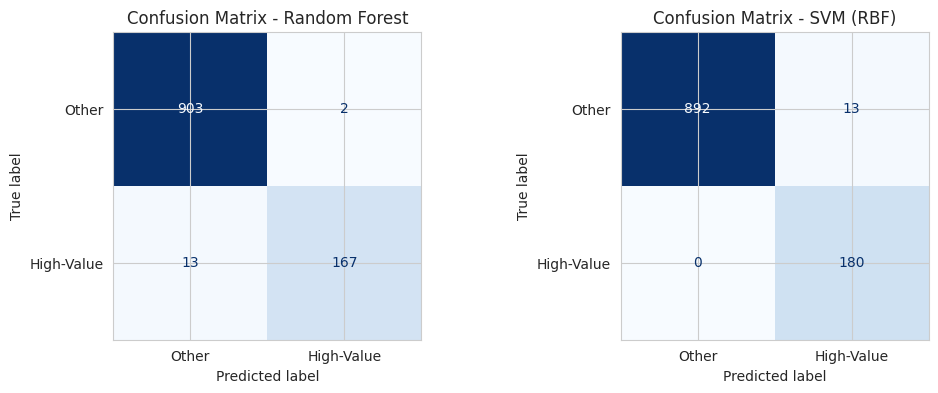

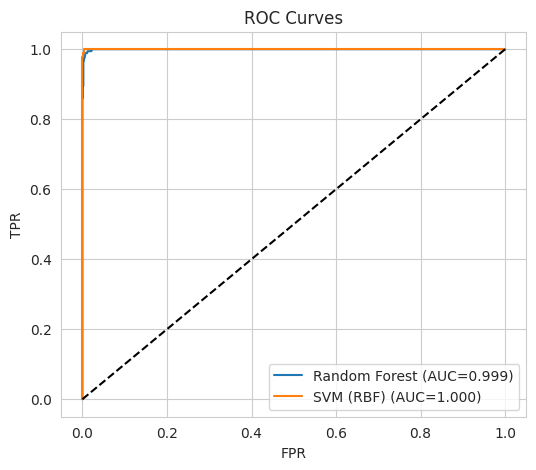

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.9862,0.9882,0.9278,0.9570,0.9995
SVM (RBF),0.9880,0.9326,1.0000,0.9651,0.9999


In [11]:
# Target: 1 if customer belongs to the high-value cluster
cust["HighValue"] = (cust["KMeans"] == hv).astype(int)
print(cust["HighValue"].value_counts(normalize=True))

# NOTE: clusters were built from these same features, so scores will be very high (label leakage).
# To make the task more realistic, drop Monetary/AvgTransactionValue from the inputs:
# SUP_FEATURES = ["Recency", "Frequency", "TotalQuantity", "PurchaseFrequency"]
SUP_FEATURES = FEATURES

Xs = pd.DataFrame(X, columns=FEATURES, index=cust.index)[SUP_FEATURES]
y = cust["HighValue"]
X_tr, X_te, y_tr, y_te = train_test_split(Xs, y, test_size=0.25, stratify=y, random_state=RS)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RS),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RS),
}

results, fig, ax = [], *plt.subplots(1, 2, figsize=(12, 4))
fig_roc = plt.figure(figsize=(6, 5))
for i, (name, m) in enumerate(models.items()):
    m.fit(X_tr, y_tr)
    pred, proba = m.predict(X_te), m.predict_proba(X_te)[:, 1]
    results.append({"Model": name, "Accuracy": accuracy_score(y_te, pred), "Precision": precision_score(y_te, pred),
                    "Recall": recall_score(y_te, pred), "F1": f1_score(y_te, pred), "ROC-AUC": roc_auc_score(y_te, proba)})
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=["Other", "High-Value"]).plot(ax=ax[i], cmap="Blues", colorbar=False)
    ax[i].set_title(f"Confusion Matrix - {name}")
    fpr, tpr, _ = roc_curve(y_te, proba)
    plt.figure(fig_roc.number); plt.plot(fpr, tpr, label=f"{name} (AUC={results[-1]['ROC-AUC']:.3f})")

plt.figure(fig_roc.number); plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curves"); plt.legend(); plt.show()
display(pd.DataFrame(results).set_index("Model").round(4))

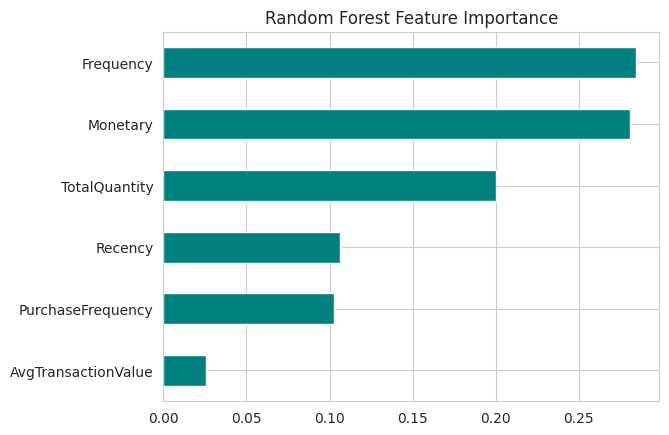

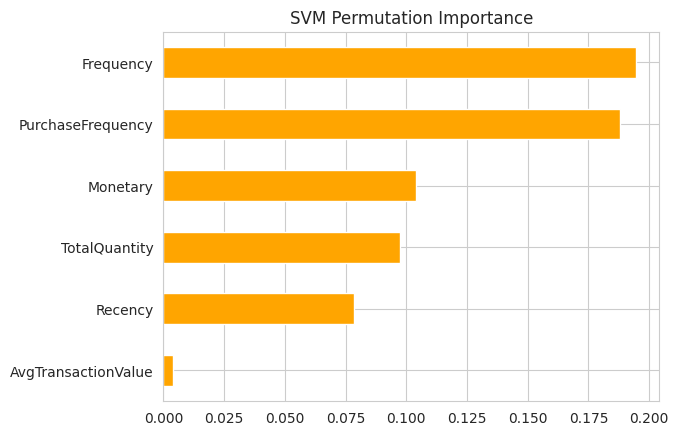

In [12]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=SUP_FEATURES).sort_values()
imp.plot(kind="barh", color="teal", title="Random Forest Feature Importance"); plt.show()

# Optional: permutation importance (works for SVM too)
from sklearn.inspection import permutation_importance
pi = permutation_importance(models["SVM (RBF)"], X_te, y_te, n_repeats=10, random_state=RS, scoring="f1")
pd.Series(pi.importances_mean, index=SUP_FEATURES).sort_values().plot(kind="barh", color="orange", title="SVM Permutation Importance")
plt.show()

In [13]:
P3 = PCA(n_components=3, random_state=RS).fit_transform(X)
plot_df = pd.DataFrame(P3, columns=["PC1", "PC2", "PC3"], index=cust.index)
plot_df["Segment"] = cust["Segment"]
plot_df = plot_df.join(cust[["Recency", "Frequency", "Monetary"]])

fig = px.scatter_3d(plot_df, x="PC1", y="PC2", z="PC3", color="Segment", opacity=0.7,
                    hover_data=["Recency", "Frequency", "Monetary"],
                    title="Interactive 3D Customer Segments (PCA)")
fig.update_traces(marker=dict(size=3))
fig.show()

# Alternative: directly on RFM (log scale)
fig2 = px.scatter_3d(cust.reset_index(), x="Recency", y="Frequency", z="Monetary", color="Segment",
                     log_y=True, log_z=True, opacity=0.7, title="3D RFM Space")
fig2.update_traces(marker=dict(size=3)); fig2.show()

In [14]:
recs = {
    "High-Value Champions": "VIP/loyalty tier, early access to new products, personalised bundles, referral rewards. Don't discount heavily; reward loyalty instead.",
    "Loyal Regulars": "Cross-sell and upsell, subscription/auto-replenish offers, points programme to push them toward the Champion tier.",
    "New / Occasional": "Welcome series, second-purchase incentive, product recommendations, free-shipping threshold to raise basket size.",
    "Dormant / At-Risk": "Win-back emails with time-limited discounts, 'we miss you' campaigns, feedback surveys; low-cost channels only.",
}
summary = profile.rename(index=names)[["Customers", "% Customers", "% Revenue", "Recency", "Frequency", "Monetary"]].copy()
summary["Recommended Strategy"] = summary.index.map(recs)
pd.set_option("display.max_colwidth", None)
display(summary)

,Customers,% Customers,% Revenue,Recency,Frequency,Monetary,Recommended Strategy
KMeans,,,,,,,
Dormant / At-Risk,1055,24.3,2.2,155.57,1.46,189.41,"Win-back emails with time-limited discounts, 'we miss you' campaigns, feedback surveys; low-cost channels only."
High-Value Champions,719,16.6,67.8,19.76,13.64,8384.19,"VIP/loyalty tier, early access to new products, personalised bundles, referral rewards. Don't discount heavily; reward loyalty instead."
New / Occasional,1065,24.6,8.4,138.03,1.42,699.90,"Welcome series, second-purchase incentive, product recommendations, free-shipping threshold to raise basket size."
Loyal Regulars,1499,34.6,21.5,50.76,3.79,1276.69,"Cross-sell and upsell, subscription/auto-replenish offers, points programme to push them toward the Champion tier."


## Conclusion
- Optimal k = 4 chosen from the elbow curve and silhouette scores; K-Means silhouette = __, Hierarchical = __, ARI = __.
- The High-Value Champions segment is __% of customers but generates __% of revenue.
- Random Forest vs SVM: RF achieved F1 = __ / ROC-AUC = __; SVM F1 = __ / ROC-AUC = __.
- Key drivers of high-value status: __ (from feature importance).
- Segment-wise marketing strategies are given in the table above.